# iTransformer — CATSA Train → EmpaticaE4 Test (ACC only)

**Model**: iTransformer (Inverted Transformer)
- 각 채널(변량)을 토큰으로 취급하고, 해당 채널의 전체 시계열을 임베딩 차원으로 사용
- 참고: *iTransformer: Inverted Transformers Are Effective for Time Series Forecasting* (Liu et al., 2024)

**학습**: CATSA 전체 피험자 (ACC 3축, 32Hz)  
**평가**: EmpaticaE4Stress (subject_01 ~ subject_06)

In [1]:
import json, math
import numpy as np
import pandas as pd
from copy import deepcopy
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt

# ── Constants ────────────────────────────────────────────────────────────
TASKS        = ["Baseline", "Logic", "Nback", "Stroop", "Sudoku"]
STRESS_TASKS = {"Logic", "Nback", "Stroop", "Sudoku"}
ACC_FS       = 32

CATSA_ROOT  = Path("/home/binghin2/Myproject/Dataset/CATSA")
E4_ROOT     = Path("/home/binghin2/Myproject/Dataset/EmpaticaE4Stress/Subjects")
SUBJECTS_E4 = [f"subject_{i:02d}" for i in range(1, 7)]
SAVE_DIR    = Path("/home/binghin2/Myproject/Research/CATSA/Train/Individual_data/ACC/Save_model_iTransformer")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── CATSA Utilities ───────────────────────────────────────────────────────
def discover_subjects(root: Path) -> List[str]:
    out = []
    for d in sorted(root.glob("Sub*"), key=lambda p: int(p.name[3:])):
        if d.is_dir() and all((d / t / "ACC.csv").exists() for t in TASKS):
            out.append(d.name)
    return out

def read_acc(path: Path) -> np.ndarray:
    df = pd.read_csv(path)
    cols = ["ACC_X", "ACC_Y", "ACC_Z"]
    if all(c in df.columns for c in cols):
        vals = df[cols].to_numpy(np.float32)
    else:
        nc = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        vals = df[nc[:3]].to_numpy(np.float32)
    return vals[~np.any(np.isnan(vals), axis=1)]

def make_windows(sig: np.ndarray, W: int, S: int) -> np.ndarray:
    if len(sig) < W:
        return np.empty((0, sig.shape[1], W), np.float32)
    return np.asarray([sig[i:i+W].T for i in range(0, len(sig)-W+1, S)], np.float32)

def build_catsa_arrays(subjects: List[str], W: int, S: int) -> Tuple[np.ndarray, np.ndarray]:
    xs, ys = [], []
    for sub in subjects:
        path = CATSA_ROOT / sub
        all_v = np.concatenate([read_acc(path / t / "ACC.csv") for t in TASKS])
        mu    = np.mean(all_v, axis=0, keepdims=True).astype(np.float32)
        sigma = (np.std(all_v, axis=0, keepdims=True) + 1e-8).astype(np.float32)
        for task in TASKS:
            norm = (read_acc(path / task / "ACC.csv") - mu) / sigma
            w    = make_windows(norm, W, S)
            if len(w):
                xs.append(w)
                ys.append(np.full(len(w), int(task in STRESS_TASKS), np.int64))
    return np.concatenate(xs), np.concatenate(ys)

# ── EmpaticaE4 Utilities ──────────────────────────────────────────────────
def build_e4_labels(n: int, fs: int = 32) -> Tuple[np.ndarray, int]:
    fixed_s = {"rest0":180,"task1":600,"rest1":120,"task2":300,"rest2":120,
               "task3":180,"rest3":120,"rest4":120,"task5":60,"rest5":120}
    task4_s = n // fs - sum(fixed_s.values())
    if task4_s <= 0:
        raise ValueError(f"Signal too short: {n/fs:.0f}s")
    segs = [("rest0",180,0),("task1",600,1),("rest1",120,-1),("task2",300,1),
            ("rest2",120,-1),("task3",180,1),("rest3",120,-1),("task4",task4_s,1),
            ("rest4",120,-1),("task5",60,1),("rest5",120,-1)]
    labels = np.full(n, -1, np.int64)
    cur = 0
    for _, dur_s, lab in segs:
        end = min(cur + dur_s * fs, n)
        if end > cur:
            labels[cur:end] = lab
        cur = end
        if cur >= n: break
    return labels, int(task4_s)

def e4_windows(acc: np.ndarray, labels: np.ndarray, W: int, S: int) -> Tuple[np.ndarray, np.ndarray]:
    mask = labels >= 0
    mu    = np.mean(acc[mask], axis=0) if mask.any() else np.mean(acc, axis=0)
    sigma = (np.std(acc[mask], axis=0) + 1e-8) if mask.any() else (np.std(acc, axis=0) + 1e-8)
    norm  = ((acc - mu) / sigma).astype(np.float32)
    xs, ys = [], []
    for i in range(0, len(norm) - W + 1, S):
        u = np.unique(labels[i:i+W])
        if len(u) == 1 and u[0] in (0, 1):
            xs.append(norm[i:i+W].T)
            ys.append(int(u[0]))
    if not xs:
        return np.empty((0, 3, W), np.float32), np.empty(0, np.int64)
    return np.asarray(xs, np.float32), np.asarray(ys, np.int64)

# ── Training Utilities ────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, alpha: Optional[float] = None):
        super().__init__()
        self.gamma, self.alpha = gamma, alpha
    def forward(self, logits: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        y   = y.float()
        bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
        pt  = torch.sigmoid(logits) * y + (1 - torch.sigmoid(logits)) * (1 - y)
        fl  = (1 - pt).pow(self.gamma) * bce
        if self.alpha is not None:
            at = self.alpha * y + (1 - self.alpha) * (1 - y)
            fl = at * fl
        return fl.mean()

def make_loader(x: np.ndarray, y: np.ndarray, bs: int, shuffle: bool) -> DataLoader:
    return DataLoader(TensorDataset(torch.from_numpy(x), torch.from_numpy(y).float()),
                      batch_size=bs, shuffle=shuffle)

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> Dict:
    model.eval()
    tot = n = tp = tn = fp = fn = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        lg = model(xb)
        tot += criterion(lg, yb).item() * len(xb)
        n   += len(xb)
        pred = (torch.sigmoid(lg) >= 0.5).long()
        yi   = yb.long()
        tp  += int(((pred==1)&(yi==1)).sum())
        tn  += int(((pred==0)&(yi==0)).sum())
        fp  += int(((pred==1)&(yi==0)).sum())
        fn  += int(((pred==0)&(yi==1)).sum())
    acc = (tp+tn)/max(n,1)
    pre = tp/max(tp+fp,1); rec = tp/max(tp+fn,1)
    f1  = 2*pre*rec/max(pre+rec,1e-8)
    return {"loss":tot/max(n,1),"accuracy":acc,"f1":f1,
            "precision":pre,"recall":rec,"tp":tp,"tn":tn,"fp":fp,"fn":fn}

def train_epoch(model: nn.Module, loader: DataLoader,
                optimizer: torch.optim.Optimizer, criterion: nn.Module) -> float:
    model.train()
    tot = n = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tot += loss.item() * len(xb); n += len(xb)
    return tot / max(n, 1)

print("Utilities loaded.")

Device: cuda
Utilities loaded.


In [2]:
# ── iTransformer Model ────────────────────────────────────────────────────
class iTransformerClassifier(nn.Module):
    """
    iTransformer: each channel (variate) is a token.
    Token embedding = linear projection of the full time series for that channel.
    Standard Transformer encoder operates on the C channel-tokens.
    """
    def __init__(self, seq_len: int = 1920, n_vars: int = 3, d_model: int = 256,
                 n_heads: int = 8, n_layers: int = 3, d_ff: int = 512,
                 dropout: float = 0.1):
        super().__init__()
        self.var_embed = nn.Linear(seq_len, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, n_vars, d_model))
        self.norm_in   = nn.LayerNorm(d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
        nn.init.normal_(self.pos_embed, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, C=3, L=1920]
        tokens = self.var_embed(x) + self.pos_embed  # [B, C, d_model]
        tokens = self.norm_in(tokens)
        out    = self.transformer(tokens)             # [B, C, d_model]
        out    = out.mean(dim=1)                      # [B, d_model]
        return self.head(out).squeeze(-1)             # [B]

# Quick architecture check
model_test = iTransformerClassifier()
x_dummy = torch.randn(4, 3, 1920)
out_test = model_test(x_dummy)
print(f"Input: {x_dummy.shape}  Output: {out_test.shape}")
n_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
del model_test, x_dummy, out_test

Input: torch.Size([4, 3, 1920])  Output: torch.Size([4])
Trainable parameters: 2,091,393


In [3]:
# ── Hyperparameters & Training on CATSA ──────────────────────────────────
HP = {
    "seed"        : 42,
    "val_ratio"   : 0.10,
    "window_size" : ACC_FS * 60,   # 1920
    "stride"      : ACC_FS * 10,   # 320
    "batch_size"  : 4,
    "epochs"      : 50,
    "lr"          : 1e-3,
    "wd"          : 1e-4,
    "patience"    : 8,
    # model
    "d_model"     : 256,
    "n_heads"     : 8,
    "n_layers"    : 3,
    "d_ff"        : 512,
    "dropout"     : 0.1,
}

np.random.seed(HP["seed"])
torch.manual_seed(HP["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(HP["seed"])

subjects = discover_subjects(CATSA_ROOT)
print(f"Total CATSA subjects: {len(subjects)}")

rng       = np.random.default_rng(HP["seed"])
idx       = rng.permutation(len(subjects))
n_val     = max(4, int(len(subjects) * HP["val_ratio"]))
val_subs  = [subjects[i] for i in sorted(idx[:n_val])]
train_subs= [subjects[i] for i in sorted(idx[n_val:])]
print(f"Train: {len(train_subs)} subjects | Val: {len(val_subs)} subjects")

W, S = HP["window_size"], HP["stride"]
print("Building training arrays...")
x_train, y_train = build_catsa_arrays(train_subs, W, S)
x_val,   y_val   = build_catsa_arrays(val_subs,   W, S)
print(f"Train: {x_train.shape}, Val: {x_val.shape}")
print(f"Train label dist  — stress: {y_train.sum()}, non-stress: {(y_train==0).sum()}")

loader_tr = make_loader(x_train, y_train, HP["batch_size"], True)
loader_va = make_loader(x_val,   y_val,   HP["batch_size"], False)

pos   = float(y_train.sum())
alpha = float((len(y_train)-pos) / len(y_train))
criterion = FocalLoss(gamma=2.0, alpha=alpha).to(DEVICE)

model = iTransformerClassifier(
    seq_len  = W,
    n_vars   = 3,
    d_model  = HP["d_model"],
    n_heads  = HP["n_heads"],
    n_layers = HP["n_layers"],
    d_ff     = HP["d_ff"],
    dropout  = HP["dropout"],
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=HP["lr"], weight_decay=HP["wd"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=4)

best_val_loss = float("inf")
best_state    = None
wait          = 0
history       = []

for epoch in range(1, HP["epochs"] + 1):
    tr_loss = train_epoch(model, loader_tr, optimizer, criterion)
    val_m   = evaluate(model, loader_va, criterion)
    scheduler.step(val_m["loss"])
    history.append({"epoch": epoch, "train_loss": tr_loss,
                    "val_loss": val_m["loss"], "val_f1": val_m["f1"]})
    if val_m["loss"] < best_val_loss:
        best_val_loss = val_m["loss"]
        best_epoch    = epoch
        wait          = 0
        best_state    = deepcopy(model.state_dict())
        torch.save({"model_state_dict": best_state, "hp": HP,
                    "epoch": epoch, "val_metrics": val_m},
                   SAVE_DIR / "best_model.pt")
    else:
        wait += 1
        if wait >= HP["patience"]:
            print(f"Early stopping at epoch {epoch} (best: {best_epoch})")
            break
    if epoch % 5 == 0 or epoch == 1:
        print(f"[{epoch:3d}] train={tr_loss:.4f}  val={val_m['loss']:.4f}  "
              f"f1={val_m['f1']:.4f}  lr={optimizer.param_groups[0]['lr']:.2e}")

model.load_state_dict(best_state)
print(f"\nTraining complete. Best epoch: {best_epoch}, best_val_loss: {best_val_loss:.4f}")

Total CATSA subjects: 50
Train: 45 subjects | Val: 5 subjects
Building training arrays...
Train: (2925, 3, 1920), Val: (325, 3, 1920)
Train label dist  — stress: 2340, non-stress: 585
[  1] train=0.0566  val=0.0549  f1=0.6192  lr=1.00e-03
[  5] train=0.0538  val=0.0525  f1=0.8116  lr=1.00e-03
[ 10] train=0.0523  val=0.0543  f1=0.8082  lr=5.00e-04
Early stopping at epoch 13 (best: 5)

Training complete. Best epoch: 5, best_val_loss: 0.0525


In [4]:
# ── Evaluate on EmpaticaE4Stress ──────────────────────────────────────────
model.eval()
all_true, all_pred = [], []
rows = []

for sub in SUBJECTS_E4:
    acc    = read_acc(E4_ROOT / sub / "ACC.csv")
    labels, task4_sec = build_e4_labels(len(acc))
    x, y_true = e4_windows(acc, labels, W, S)

    if len(x) == 0:
        rows.append({"subject": sub, "n_windows": 0,
                     "accuracy": float("nan"), "f1": float("nan"),
                     "precision": float("nan"), "recall": float("nan")})
        continue

    with torch.no_grad():
        logits = model(torch.from_numpy(x).to(DEVICE))
        y_pred = (torch.sigmoid(logits) >= 0.5).cpu().numpy().astype(int)

    rows.append({
        "subject"  : sub,
        "task4_sec": task4_sec,
        "n_windows": len(y_true),
        "accuracy" : float(accuracy_score(y_true, y_pred)),
        "f1"       : float(f1_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall"   : float(recall_score(y_true, y_pred, zero_division=0)),
    })
    all_true.extend(y_true.tolist())
    all_pred.extend(y_pred.tolist())

result_df = pd.DataFrame(rows)
print("=== Per-subject metrics ===")
display(result_df)

if all_true:
    ov_acc  = accuracy_score(all_true, all_pred)
    ov_f1   = f1_score(all_true, all_pred, zero_division=0)
    ov_prec = precision_score(all_true, all_pred, zero_division=0)
    ov_rec  = recall_score(all_true, all_pred, zero_division=0)
    print(f"\n=== Overall (subject_01~06) ===")
    print(f"Accuracy : {ov_acc:.4f}")
    print(f"F1       : {ov_f1:.4f}")
    print(f"Precision: {ov_prec:.4f}")
    print(f"Recall   : {ov_rec:.4f}")
    cm = confusion_matrix(all_true, all_pred)
    print("\nConfusion Matrix [rows=true, cols=pred]")
    print(cm)
    print("\nClassification Report")
    print(classification_report(all_true, all_pred,
                                target_names=["Non-stress","Stress"], zero_division=0))

=== Per-subject metrics ===


,subject,task4_sec,n_windows,accuracy,f1,precision,recall
0,subject_01,585,159,0.911950,0.952381,0.945946,0.958904
1,subject_02,435,144,0.729167,0.842105,0.896552,0.793893
2,subject_03,156,116,0.939655,0.964824,1.000000,0.932039
3,subject_04,188,119,0.806723,0.878307,1.000000,0.783019
4,subject_05,163,117,0.410256,0.581818,0.786885,0.461538
5,subject_06,243,125,0.816000,0.898678,0.886957,0.910714



=== Overall (subject_01~06) ===
Accuracy : 0.7756
F1       : 0.8675
Precision: 0.9257
Recall   : 0.8162

Confusion Matrix [rows=true, cols=pred]
[[ 32  46]
 [129 573]]

Classification Report
              precision    recall  f1-score   support

  Non-stress       0.20      0.41      0.27        78
      Stress       0.93      0.82      0.87       702

    accuracy                           0.78       780
   macro avg       0.56      0.61      0.57       780
weighted avg       0.85      0.78      0.81       780



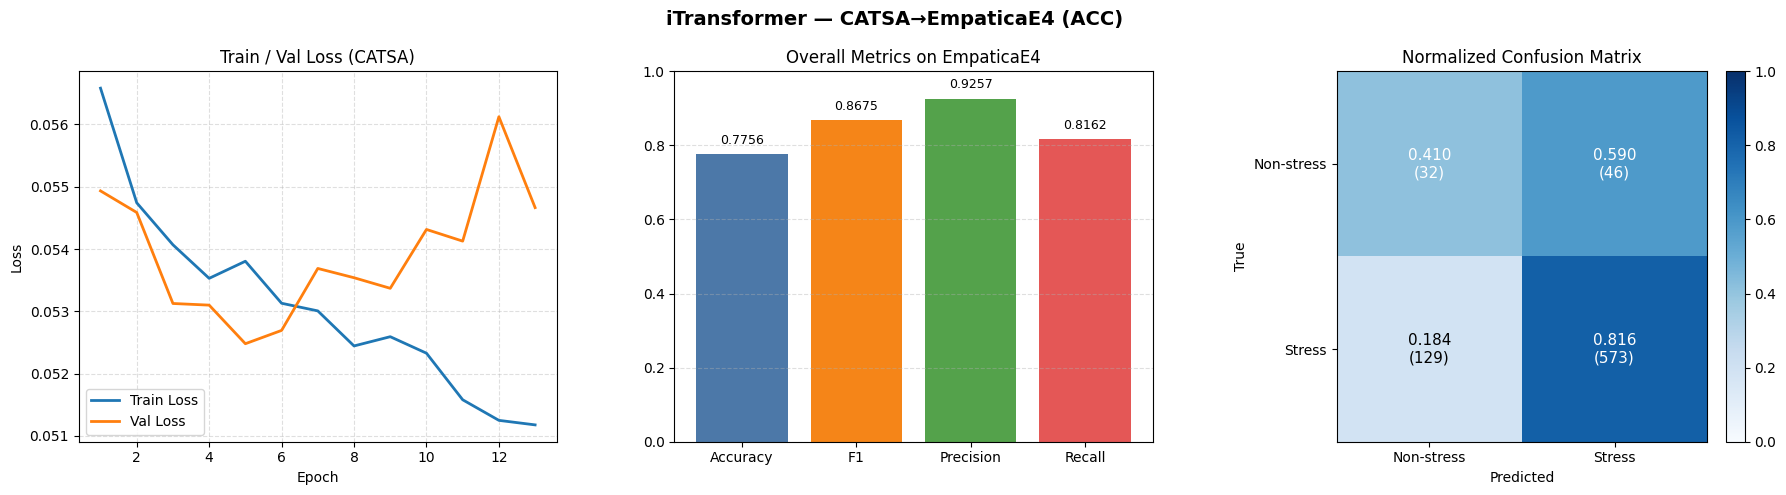

Saved results.png


In [5]:
# ── Visualization ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Train / Val Loss
epochs_list = [h["epoch"]      for h in history]
tr_losses   = [h["train_loss"] for h in history]
va_losses   = [h["val_loss"]   for h in history]
axes[0].plot(epochs_list, tr_losses, label="Train Loss", linewidth=2)
axes[0].plot(epochs_list, va_losses, label="Val Loss",   linewidth=2)
axes[0].set_title("Train / Val Loss (CATSA)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(linestyle="--", alpha=0.4)

# 2) Overall metrics bar
if all_true:
    metrics_labels = ["Accuracy", "F1", "Precision", "Recall"]
    metrics_vals   = [ov_acc, ov_f1, ov_prec, ov_rec]
    bars = axes[1].bar(metrics_labels, metrics_vals,
                       color=["#4C78A8","#F58518","#54A24B","#E45756"])
    axes[1].set_ylim(0, 1.0)
    axes[1].set_title("Overall Metrics on EmpaticaE4")
    axes[1].grid(axis="y", linestyle="--", alpha=0.4)
    for b, v in zip(bars, metrics_vals):
        axes[1].text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.4f}",
                     ha="center", va="bottom", fontsize=9)

# 3) Confusion Matrix (row-normalized)
if all_true:
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    im = axes[2].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    axes[2].set_title("Normalized Confusion Matrix")
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
    axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
    axes[2].set_xticklabels(["Non-stress","Stress"])
    axes[2].set_yticklabels(["Non-stress","Stress"])
    thr = cm_norm.max() / 2
    for i in range(2):
        for j in range(2):
            axes[2].text(j, i, f"{cm_norm[i,j]:.3f}\n({cm[i,j]})",
                         ha="center", va="center",
                         color="white" if cm_norm[i,j] > thr else "black", fontsize=11)
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

fig.suptitle("iTransformer — CATSA→EmpaticaE4 (ACC)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results.png")